TASK 5: SALES PREDICTION USING PYTHON

AICTE Oasis Infobyte Internship


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [14]:
# ----------------------------------------------------------
# HELPER: Create realistic advertising/sales dataset
# ----------------------------------------------------------
def create_sample_data(n=500):
    np.random.seed(42)
    segments = ['Youth', 'Middle Aged', 'Old']
    platforms = ['YouTube', 'Instagram', 'Facebook', 'Twitter', 'Google Ads']
    records = []
    for i in range(n):
        tv      = np.random.uniform(0.1, 300)
        radio   = np.random.uniform(0.1, 100)
        news    = np.random.uniform(0.1, 50)
        segment = np.random.choice(segments)
        platform = np.random.choice(platforms)
        # Sales formula with noise
        sales = (0.045 * tv + 0.18 * radio - 0.001 * news**1.5
                 + 2.5 + np.random.normal(0, 1.5))
        sales = max(1.5, round(sales, 2))
        records.append({
            'TV':           round(tv, 1),
            'Radio':        round(radio, 1),
            'Newspaper':    round(news, 1),
            'Sales':        sales,
            'Segment':      segment,
            'Platform':     platform,
        })
    return pd.DataFrame(records)


In [15]:
# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
print("=" * 60)
print("         SALES PREDICTION USING PYTHON")
print("=" * 60)

try:
    df = pd.read_csv('advertising.csv')
    print("\n[1] Dataset loaded from advertising.csv")
except FileNotFoundError:
    try:
        df = pd.read_csv('sales_data_sample.csv', encoding='latin-1')
        print("\n[1] Dataset loaded from sales_data_sample.csv")
    except FileNotFoundError:
        print("\n[1] CSV not found — using generated sample data.")
        print("    (Place 'advertising.csv' in the same folder for real data.)")
        df = create_sample_data()

print(f"    Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")


         SALES PREDICTION USING PYTHON

[1] CSV not found — using generated sample data.
    (Place 'advertising.csv' in the same folder for real data.)
    Shape: (500, 6)

First 5 rows:
      TV  Radio  Newspaper  Sales      Segment    Platform
0  112.4   95.1       36.6  24.10        Youth  Google Ads
1   17.5   86.6       30.1  18.37          Old  Google Ads
2  291.0   83.3       10.7  30.91        Youth     YouTube
3  129.6   29.2       30.6  10.55  Middle Aged     Twitter
4  292.1   23.4        4.6  20.05  Middle Aged    Facebook


In [16]:
# 2. DATA CLEANING & PREPROCESSING
print("\n[2] Data Cleaning...")

# Standardize column names
df.columns = df.columns.str.strip().str.title()

# Detect target column
target_col = next((c for c in df.columns if 'sales' in c.lower()), None)
if target_col is None:
    raise ValueError("Could not find a 'Sales' column in the dataset.")

print(f"    Target column: {target_col}")

# Detect advertising spend columns
spend_cols = [c for c in df.columns if any(k in c.lower() for k in ['tv', 'radio', 'newspaper', 'social', 'digital'])]
print(f"    Spend columns: {spend_cols}")

df.dropna(subset=[target_col], inplace=True)
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

print(f"    Cleaned shape: {df.shape}")
print(f"\nStatistical Summary:\n{df.describe()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")


[2] Data Cleaning...
    Target column: Sales
    Spend columns: ['Tv', 'Radio', 'Newspaper']
    Cleaned shape: (500, 6)

Statistical Summary:
               Tv       Radio   Newspaper       Sales
count  500.000000  500.000000  500.000000  500.000000
mean   156.220600   51.153400   25.052800   18.707480
std     87.774639   29.646208   14.239339    6.843015
min      0.700000    0.100000    0.100000    2.490000
25%     77.975000   24.675000   12.875000   13.662500
50%    163.900000   52.400000   25.000000   19.040000
75%    236.000000   77.850000   36.825000   23.105000
max    299.300000  100.000000   49.800000   33.110000

Missing Values:
Tv           0
Radio        0
Newspaper    0
Sales        0
Segment      0
Platform     0
dtype: int64



[3] Generating EDA Visualizations...


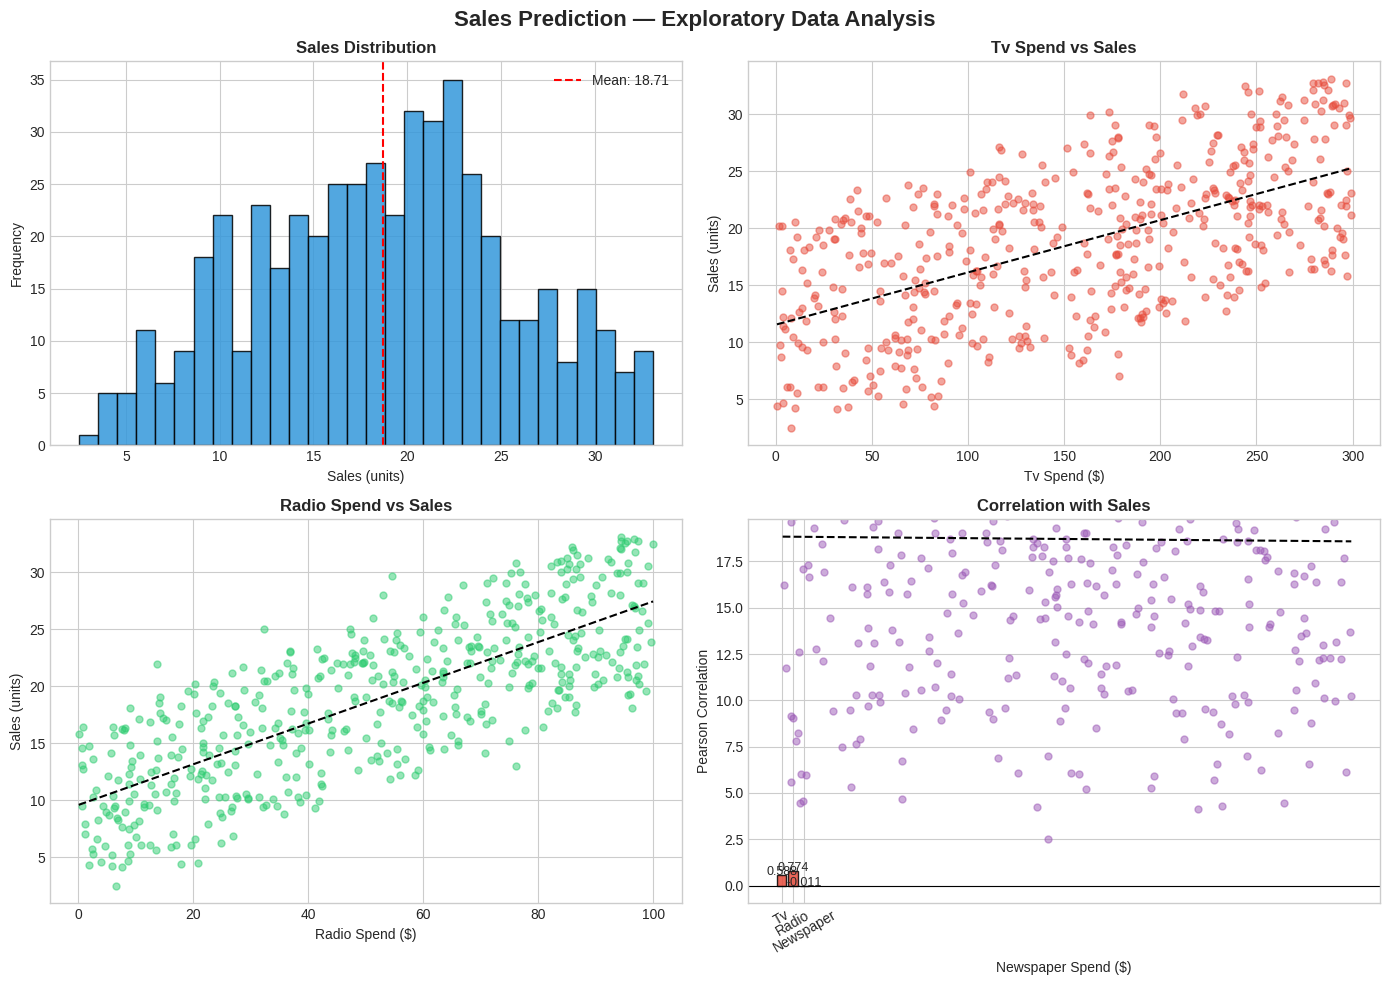

    Saved: sales_eda.png


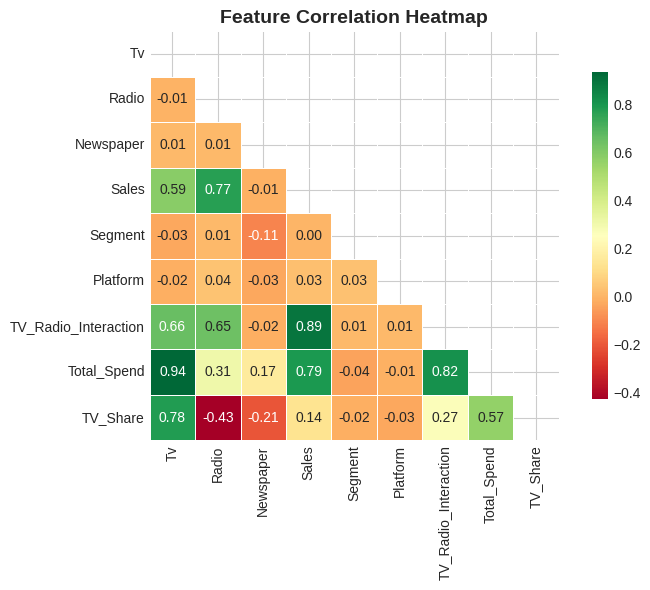

    Saved: sales_correlation.png


In [25]:
# 3. EDA VISUALIZATIONS
print("\n[3] Generating EDA Visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sales Prediction — Exploratory Data Analysis", fontsize=16, fontweight='bold')

# Sales distribution
axes[0, 0].hist(df[target_col], bins=30, color='#3498db', edgecolor='black', alpha=0.85)
axes[0, 0].axvline(df[target_col].mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Mean: {df[target_col].mean():.2f}")
axes[0, 0].set_title('Sales Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Sales (units)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Scatter plots: each ad channel vs sales
colors = ['#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
if spend_cols:
    for idx, col in enumerate(spend_cols[:3]):
        ax = axes[0, 1] if idx == 0 else axes[1, idx - 1]
        ax.scatter(df[col], df[target_col], alpha=0.5, color=colors[idx], s=25)
        # Trend line
        z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), target_col], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[col].min(), df[col].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', linewidth=1.5)
        ax.set_title(f'{col} Spend vs Sales', fontweight='bold')
        ax.set_xlabel(f'{col} Spend ($)')
        ax.set_ylabel('Sales (units)')

# Pairwise correlation if needed
if len(spend_cols) > 0:
    # Last plot: correlation bar
    numeric_df = df[[*spend_cols, target_col]].select_dtypes(include='number')
    corr_vals = numeric_df.corr()[target_col].drop(target_col)
    bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_vals]
    axes[1, 1].bar(corr_vals.index, corr_vals.values, color=bar_colors, edgecolor='black', alpha=0.85)
    axes[1, 1].set_title(f'Correlation with {target_col}', fontweight='bold')
    axes[1, 1].set_ylabel('Pearson Correlation')
    axes[1, 1].tick_params(axis='x', rotation=30)
    axes[1, 1].axhline(0, color='black', linewidth=0.8)
    for bar, val in zip(axes[1, 1].patches, corr_vals.values):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.01 * np.sign(val),
                        f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('sales_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: sales_eda.png")

# Correlation Heatmap
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8, 6))
    corr = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                linewidths=0.5, square=True, mask=mask,
                cbar_kws={'shrink': 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sales_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("    Saved: sales_correlation.png")

In [18]:
# 4. FEATURE ENGINEERING
print("\n[4] Feature Engineering...")

# Create interaction features
if 'Tv' in df.columns and 'Radio' in df.columns:
    df['TV_Radio_Interaction'] = df['Tv'] * df['Radio']
    df['Total_Spend'] = df['Tv'] + df['Radio'] + df.get('Newspaper', pd.Series(0, index=df.index))
    df['TV_Share'] = df['Tv'] / (df['Total_Spend'] + 1e-5)
elif len(spend_cols) >= 2:
    df['Total_Spend'] = df[spend_cols].sum(axis=1)

# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"    Features after engineering: {list(df.columns)}")


[4] Feature Engineering...
    Features after engineering: ['Tv', 'Radio', 'Newspaper', 'Sales', 'Segment', 'Platform', 'TV_Radio_Interaction', 'Total_Spend', 'TV_Share']


In [19]:
# 5. MODEL TRAINING & EVALUATION
print("\n[5] Training Multiple Models...")
print("-" * 55)

feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"    Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Lasso Regression':     Lasso(alpha=0.01),
    'Decision Tree':        DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=150, random_state=42),
    'SVR':                  SVR(kernel='rbf', C=10, epsilon=0.2),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    results[name] = {'model': model, 'y_pred': y_pred, 'mae': mae, 'rmse': rmse, 'r2': r2,
                     'cv_mean': cv.mean(), 'cv_std': cv.std()}
    print(f"    {name:<22} | MAE:{mae:>6.3f} | RMSE:{rmse:>6.3f} | R²:{r2:.4f} | CV:{cv.mean():.4f}±{cv.std():.4f}")


[5] Training Multiple Models...
-------------------------------------------------------
    Train: 400 | Test: 100
    Linear Regression      | MAE: 1.092 | RMSE: 1.365 | R²:0.9613 | CV:0.9459±0.0069
    Ridge Regression       | MAE: 1.092 | RMSE: 1.367 | R²:0.9612 | CV:0.9459±0.0070
    Lasso Regression       | MAE: 1.085 | RMSE: 1.357 | R²:0.9618 | CV:0.9460±0.0069
    Decision Tree          | MAE: 1.574 | RMSE: 2.000 | R²:0.9169 | CV:0.9036±0.0107
    Random Forest          | MAE: 1.227 | RMSE: 1.577 | R²:0.9483 | CV:0.9322±0.0067
    Gradient Boosting      | MAE: 1.235 | RMSE: 1.584 | R²:0.9478 | CV:0.9340±0.0084
    SVR                    | MAE: 1.459 | RMSE: 1.809 | R²:0.9320 | CV:0.9303±0.0120


In [20]:
# 6. BEST MODEL
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
print(f"\n[6] Best Model: {best_name}")
print(f"    R² Score : {best['r2']:.4f}")
print(f"    MAE      : {best['mae']:.4f}")
print(f"    RMSE     : {best['rmse']:.4f}")

# Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Sales Prediction Results — {best_name}", fontsize=14, fontweight='bold')

# Actual vs Predicted scatter
axes[0].scatter(y_test, best['y_pred'], alpha=0.6, color='#3498db', s=25, edgecolors='white')
lims = [min(y_test.min(), best['y_pred'].min()), max(y_test.max(), best['y_pred'].max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test.values - best['y_pred']
axes[1].scatter(best['y_pred'], residuals, alpha=0.5, color='#e74c3c', s=20)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

# R² Model Comparison
model_names = list(results.keys())
r2_scores = [results[m]['r2'] for m in model_names]
bar_colors = ['#e74c3c' if m == best_name else '#3498db' for m in model_names]
bars = axes[2].bar(range(len(model_names)), r2_scores, color=bar_colors, edgecolor='black', alpha=0.85)
axes[2].set_xticks(range(len(model_names)))
axes[2].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7)
axes[2].set_ylabel('R² Score')
axes[2].set_title('Model Comparison (R²)', fontweight='bold')
for bar, score in zip(bars, r2_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{score:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('sales_model_results.png', dpi=150, bbox_inches='tight')
plt.close()
print("    Saved: sales_model_results.png")


[6] Best Model: Lasso Regression
    R² Score : 0.9618
    MAE      : 1.0855
    RMSE     : 1.3568
    Saved: sales_model_results.png


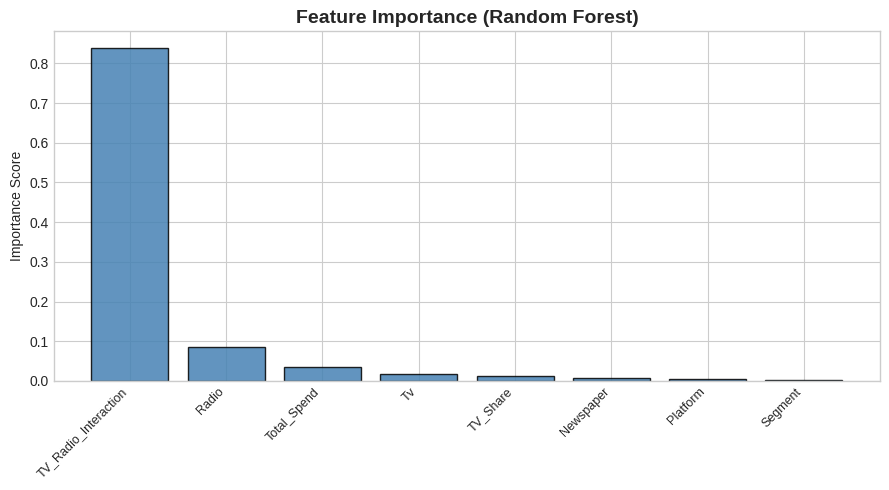

    Saved: sales_feature_importance.png


In [26]:
# 7. FEATURE IMPORTANCE
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_names = feature_cols
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(feat_names)), importances[sorted_idx], color='steelblue', edgecolor='black', alpha=0.85)
plt.xticks(range(len(feat_names)), [feat_names[i] for i in sorted_idx], rotation=45, ha='right', fontsize=9)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('sales_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: sales_feature_importance.png")

In [22]:
# 8. AD BUDGET OPTIMIZER (practical insight)
if 'Tv' in df.columns and 'Radio' in df.columns:
    print("\n[7] Ad Budget Optimization Insights:")
    budgets = [100, 200, 300]
    for total_budget in budgets:
        best_sales = 0
        best_split = None
        for tv_share in range(0, 101, 10):
            tv_spend = total_budget * tv_share / 100
            radio_spend = total_budget * (1 - tv_share / 100)
            sample = pd.DataFrame({'Tv': [tv_spend], 'Radio': [radio_spend], 'Newspaper': [0]})
            if 'TV_Radio_Interaction' in df.columns:
                sample['TV_Radio_Interaction'] = tv_spend * radio_spend
                sample['Total_Spend'] = total_budget
                sample['TV_Share'] = tv_spend / (total_budget + 1e-5)
            for cat in cat_cols:
                if cat in feature_cols:
                    sample[cat] = 0
            sample = sample.reindex(columns=feature_cols, fill_value=0)
            pred = results['Random Forest']['model'].predict(scaler.transform(sample))[0]
            if pred > best_sales:
                best_sales = pred
                best_split = (tv_spend, radio_spend)
        print(f"    Budget ${total_budget}: Best split → TV ${best_split[0]:.0f} | Radio ${best_split[1]:.0f} → Predicted Sales: {best_sales:.2f}")


[7] Ad Budget Optimization Insights:
    Budget $100: Best split → TV $0 | Radio $100 → Predicted Sales: 19.57
    Budget $200: Best split → TV $100 | Radio $100 → Predicted Sales: 22.81
    Budget $300: Best split → TV $150 | Radio $150 → Predicted Sales: 29.63



[7.1] Ad Budget Optimization Visualizations:


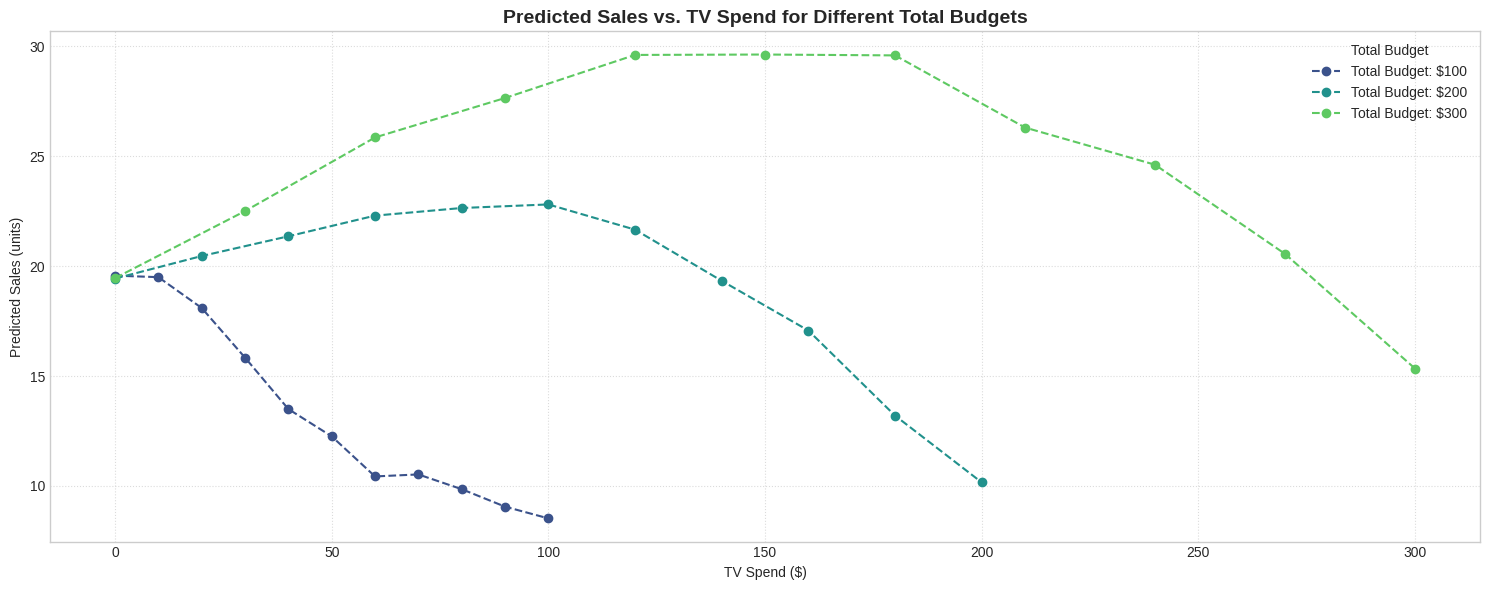

    Saved: sales_budget_optimization.png


In [24]:
print("\n[7.1] Ad Budget Optimization Visualizations:")

budgets = [100, 200, 300] # Re-define budgets for the plot
all_results = []

for total_budget in budgets:
    for tv_share in range(0, 101, 10):
        tv_spend = total_budget * tv_share / 100
        radio_spend = total_budget * (1 - tv_share / 100)

        # Create a sample DataFrame for prediction
        sample = pd.DataFrame({'Tv': [tv_spend], 'Radio': [radio_spend], 'Newspaper': [0]})
        if 'TV_Radio_Interaction' in df.columns:
            sample['TV_Radio_Interaction'] = tv_spend * radio_spend
            sample['Total_Spend'] = total_budget
            sample['TV_Share'] = tv_spend / (total_budget + 1e-5)
        for cat in cat_cols:
            if cat in feature_cols:
                sample[cat] = 0
        sample = sample.reindex(columns=feature_cols, fill_value=0)

        # Predict sales using the best model (Random Forest was used in the text output)
        pred = results['Random Forest']['model'].predict(scaler.transform(sample))[0]
        all_results.append({
            'Budget': total_budget,
            'TV_Spend': tv_spend,
            'Radio_Spend': radio_spend,
            'Predicted_Sales': pred
        })

results_df = pd.DataFrame(all_results)

plt.figure(figsize=(15, 6))
# Define a custom color palette
colors = sns.color_palette("viridis", n_colors=len(budgets))

for i, budget in enumerate(budgets):
    subset = results_df[results_df['Budget'] == budget]
    plt.plot(subset['TV_Spend'], subset['Predicted_Sales'], marker='o', linestyle='--', label=f'Total Budget: ${budget}', color=colors[i])

plt.title('Predicted Sales vs. TV Spend for Different Total Budgets', fontsize=14, fontweight='bold')
plt.xlabel('TV Spend ($)')
plt.ylabel('Predicted Sales (units)')
plt.legend(title='Total Budget')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('sales_budget_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: sales_budget_optimization.png")

In [23]:
# 9. DEMO PREDICTIONS
print("\n[8] Sample Predictions:")
sample_rows = X_test.iloc[:5]
sample_preds = results[best_name]['model'].predict(scaler.transform(sample_rows))
actuals = y_test.iloc[:5].values
for i, (a, p) in enumerate(zip(actuals, sample_preds)):
    print(f"    Sample {i+1}: Actual={a:.2f}  Predicted={p:.2f}  Error={abs(a-p):.2f}")

print("\n" + "=" * 60)
print("  SALES PREDICTION COMPLETE!")
print("=" * 60)


[8] Sample Predictions:
    Sample 1: Actual=23.53  Predicted=22.68  Error=0.85
    Sample 2: Actual=12.29  Predicted=13.55  Error=1.26
    Sample 3: Actual=21.90  Predicted=21.94  Error=0.04
    Sample 4: Actual=33.11  Predicted=32.94  Error=0.17
    Sample 5: Actual=13.80  Predicted=14.78  Error=0.98

  SALES PREDICTION COMPLETE!
